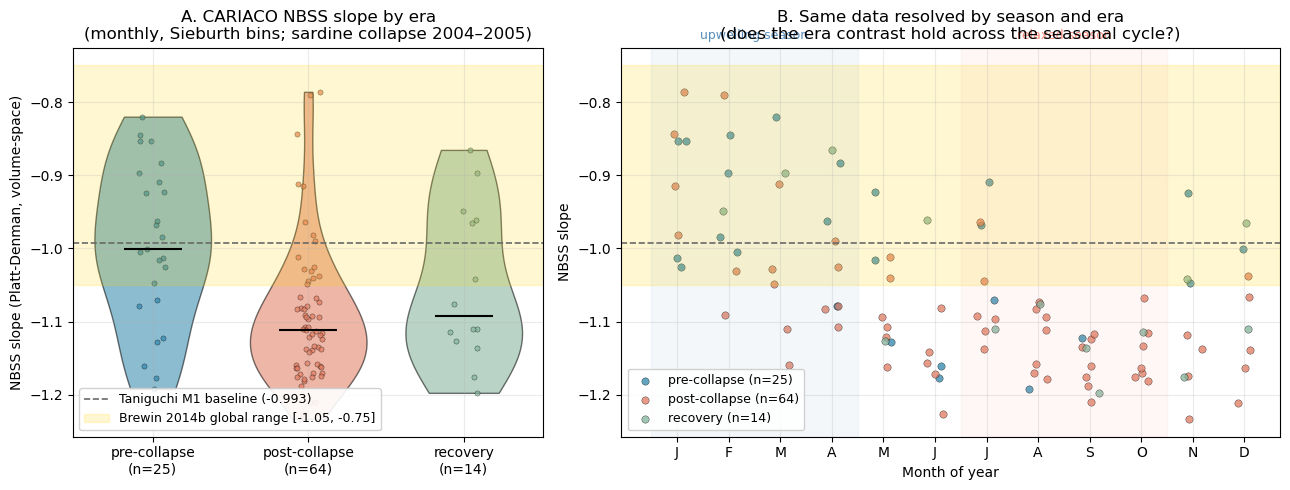

Era medians:
               count  median   mean
era                                
post-collapse     64  -1.112 -1.094
pre-collapse      25  -1.001 -0.994
recovery          14  -1.093 -1.052


In [8]:
# CELL A — Cariaco NBSS slope: era distribution + per-month seasonal pattern
# Run from code/ directory (so the CSV relative path resolves), or set CSV_PATH explicitly.

import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Path mirrors cariaco_obs.DEFAULT_CSV_PATH (../data/processed/...).
# If your notebook lives elsewhere, set CSV_PATH manually.
CSV_PATH = os.path.join('..', 'data', 'processed', 'cariaco_monthly_euphotic_dynamic.csv')
import sys, os, time, warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
sys.path.insert(0, os.path.abspath('../model'))
sys.path.insert(0, os.path.abspath('../parameter_scan'))

df = pd.read_csv(CSV_PATH, parse_dates=['date'])
df = df.dropna(subset=['nbss_slope']).copy()
df['year']  = df['date'].dt.year
df['month'] = df['date'].dt.month

# Era definitions match project_obs_envelope.md
def assign_era(year):
    if year < 2005:   return 'pre-collapse'
    if year < 2014:   return 'post-collapse'
    return 'recovery'

df['era'] = df['year'].apply(assign_era)
era_order  = ['pre-collapse', 'post-collapse', 'recovery']
era_colors = {'pre-collapse': '#2E86AB', 'post-collapse': '#E07A5F', 'recovery': '#81B29A'}

# Reference anchors (per Taniguchi_Model1_Baseline.tex and project_obs_envelope.md)
TANIGUCHI_BASELINE = -0.993
BREWIN_LOW, BREWIN_HIGH = -1.05, -0.75

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5.0), gridspec_kw={'width_ratios': [1, 1.4]})

# ---------- LEFT PANEL: era violins ----------
data_by_era = [df.loc[df['era'] == e, 'nbss_slope'].values for e in era_order]
parts = axL.violinplot(data_by_era, positions=range(len(era_order)),
                       showmedians=True, showextrema=False, widths=0.75)
for body, era in zip(parts['bodies'], era_order):
    body.set_facecolor(era_colors[era]); body.set_edgecolor('black'); body.set_alpha(0.55)
parts['cmedians'].set_color('black'); parts['cmedians'].set_linewidth(1.5)

# Per-month jitter overlay so the supervisor sees the n
rng = np.random.default_rng(0)
for i, e in enumerate(era_order):
    y = df.loc[df['era'] == e, 'nbss_slope'].values
    x = i + (rng.random(len(y)) - 0.5) * 0.18
    axL.scatter(x, y, s=14, color=era_colors[e], edgecolor='black', linewidth=0.3, alpha=0.7)

axL.axhline(TANIGUCHI_BASELINE, color='dimgray', ls='--', lw=1.2,
            label=f'Taniguchi M1 baseline ({TANIGUCHI_BASELINE:.3f})')
axL.axhspan(BREWIN_LOW, BREWIN_HIGH, color='gold', alpha=0.18,
            label=f'Brewin 2014b global range [{BREWIN_LOW:.2f}, {BREWIN_HIGH:.2f}]')
axL.set_xticks(range(len(era_order)))
axL.set_xticklabels([f'{e}\n(n={len(d)})' for e, d in zip(era_order, data_by_era)])
axL.set_ylabel('NBSS slope (Platt-Denman, volume-space)')
axL.set_title('A. CARIACO NBSS slope by era\n(monthly, Sieburth bins; sardine collapse 2004–2005)')
axL.legend(loc='lower left', fontsize=9, framealpha=0.9)
axL.grid(alpha=0.25)

# ---------- RIGHT PANEL: per-month seasonal scatter ----------
for e in era_order:
    sub = df[df['era'] == e]
    axR.scatter(sub['month'] + rng.uniform(-0.18, 0.18, len(sub)),
                sub['nbss_slope'],
                s=28, color=era_colors[e], edgecolor='black', linewidth=0.3,
                alpha=0.75, label=f'{e} (n={len(sub)})')

axR.axhline(TANIGUCHI_BASELINE, color='dimgray', ls='--', lw=1.2)
axR.axhspan(BREWIN_LOW, BREWIN_HIGH, color='gold', alpha=0.18)

# Annotate upwelling vs relaxed season for Cariaco (DJF / JF cool upwelling; JJA warm relaxed)
axR.axvspan(0.5, 4.5, color='steelblue', alpha=0.06)  # upwelling-favoured months
axR.axvspan(6.5, 10.5, color='salmon',   alpha=0.06)  # relaxed-favoured months
axR.text(2.5, axR.get_ylim()[1] if False else -0.7, 'upwelling season',
         ha='center', va='top', fontsize=9, color='steelblue', alpha=0.9)
axR.text(8.5, -0.7, 'relaxed season',
         ha='center', va='top', fontsize=9, color='salmon', alpha=0.9)

axR.set_xticks(range(1, 13))
axR.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
axR.set_xlabel('Month of year')
axR.set_ylabel('NBSS slope')
axR.set_title('B. Same data resolved by season and era\n(does the era contrast hold across the seasonal cycle?)')
axR.legend(loc='lower left', fontsize=9, framealpha=0.9)
axR.grid(alpha=0.25)

# Match y-axis ranges
y_all_lo = min(axL.get_ylim()[0], axR.get_ylim()[0])
y_all_hi = max(axL.get_ylim()[1], axR.get_ylim()[1])
axL.set_ylim(y_all_lo, y_all_hi); axR.set_ylim(y_all_lo, y_all_hi)

plt.tight_layout()
#plt.savefig('fig_obs_nbss_era_season.png', dpi=160, bbox_inches='tight')
plt.show()

# Quick summary printout for sanity / supervisor talking points
print('Era medians:')
print(df.groupby('era')['nbss_slope'].agg(['count', 'median', 'mean']).round(3))

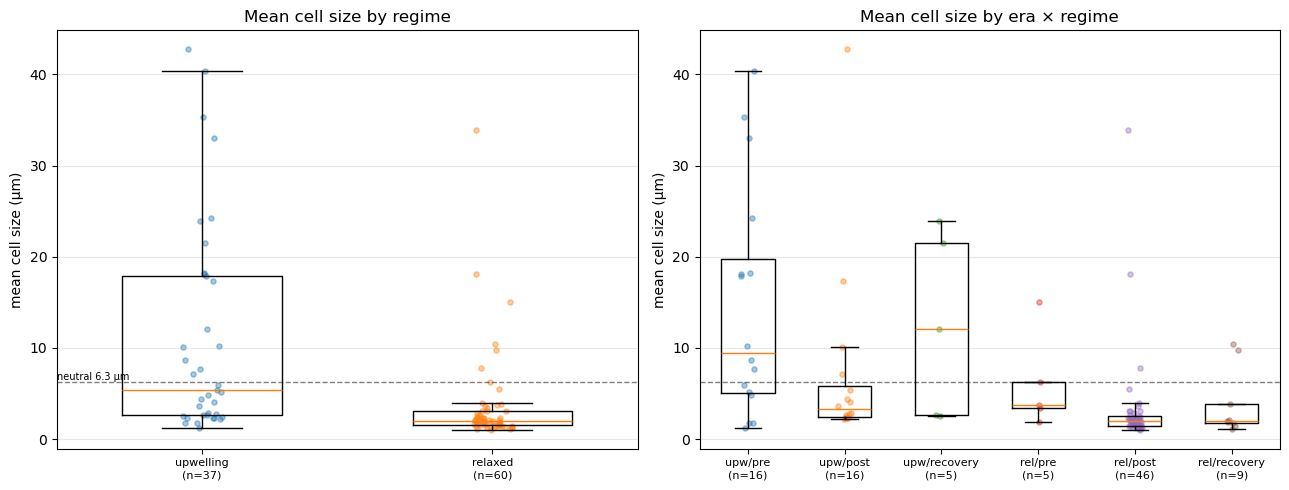

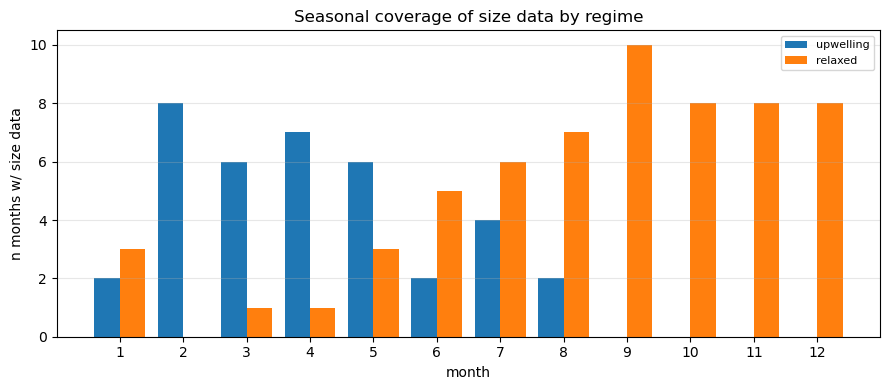

n months with size data (era × regime):
era              pre  post  recovery
regime_adjusted                     
upwelling         16    16         5
relaxed            5    46         9


In [9]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from cariaco_obs import DEFAULT_CSV_PATH

df = pd.read_csv(DEFAULT_CSV_PATH)
df['date'] = pd.to_datetime(df['date'])
df['mean_cell_um'] = 10.0 ** df['size_centroid']
df['era'] = np.where(df['date'] < '2005-01-01', 'pre',
            np.where(df['date'] < '2014-01-01', 'post', 'recovery'))
REG = ['upwelling', 'relaxed']
d = df[df['regime_adjusted'].isin(REG)].copy()
rng = np.random.RandomState(0)

def boxstrip(ax, groups, labs, neutral=None):
    pos = [i for i, v in enumerate(groups, 1) if len(v)]
    vv  = [v for v in groups if len(v)]
    if vv: ax.boxplot(vv, positions=pos, showfliers=False, widths=0.55)
    for i, v in enumerate(groups, 1):
        if len(v): ax.scatter(i + (rng.rand(len(v)) - .5) * .14, v, s=14, alpha=.4)
    ax.set_xticks(range(1, len(groups) + 1)); ax.set_xticklabels(labs, fontsize=8)
    if neutral is not None: ax.axhline(neutral, color='k', ls='--', lw=1, alpha=.5)
    ax.grid(alpha=.3, axis='y')

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
gv = [d.loc[d.regime_adjusted == r, 'mean_cell_um'].dropna().values for r in REG]
boxstrip(ax[0], gv, [f"{r}\n(n={len(v)})" for r, v in zip(REG, gv)], neutral=10**0.80)
ax[0].set_ylabel('mean cell size (µm)'); ax[0].set_title('Mean cell size by regime')
ax[0].annotate('neutral 6.3 µm', (0.5, 10**0.80), fontsize=7, va='bottom')

order = [(r, e) for r in REG for e in ['pre', 'post', 'recovery']]
gv2 = [d[(d.regime_adjusted == r) & (d.era == e)]['mean_cell_um'].dropna().values for r, e in order]
boxstrip(ax[1], gv2, [f"{r[:3]}/{e}\n(n={len(v)})" for (r, e), v in zip(order, gv2)], neutral=10**0.80)
ax[1].set_ylabel('mean cell size (µm)'); ax[1].set_title('Mean cell size by era × regime')
fig.tight_layout(); plt.show()

# Seasonal coverage of size data by regime
d['moy'] = d['date'].dt.month
fig2, axc = plt.subplots(figsize=(9, 4))
for off, r, c in [(-0.2, 'upwelling', 'C0'), (0.2, 'relaxed', 'C1')]:
    cnt = (d[(d.regime_adjusted == r) & d.mean_cell_um.notna()]['moy']
           .value_counts().reindex(range(1, 13), fill_value=0))
    axc.bar(np.arange(1, 13) + off, cnt.values, width=0.4, label=r, color=c)
axc.set_xticks(range(1, 13)); axc.set_xlabel('month'); axc.set_ylabel('n months w/ size data')
axc.set_title('Seasonal coverage of size data by regime'); axc.legend(fontsize=8); axc.grid(alpha=.3, axis='y')
fig2.tight_layout(); plt.show()

print("n months with size data (era × regime):")
print(d[d.mean_cell_um.notna()].groupby(['regime_adjusted', 'era']).size()
      .unstack().reindex(REG)[['pre', 'post', 'recovery']].fillna(0).astype(int))

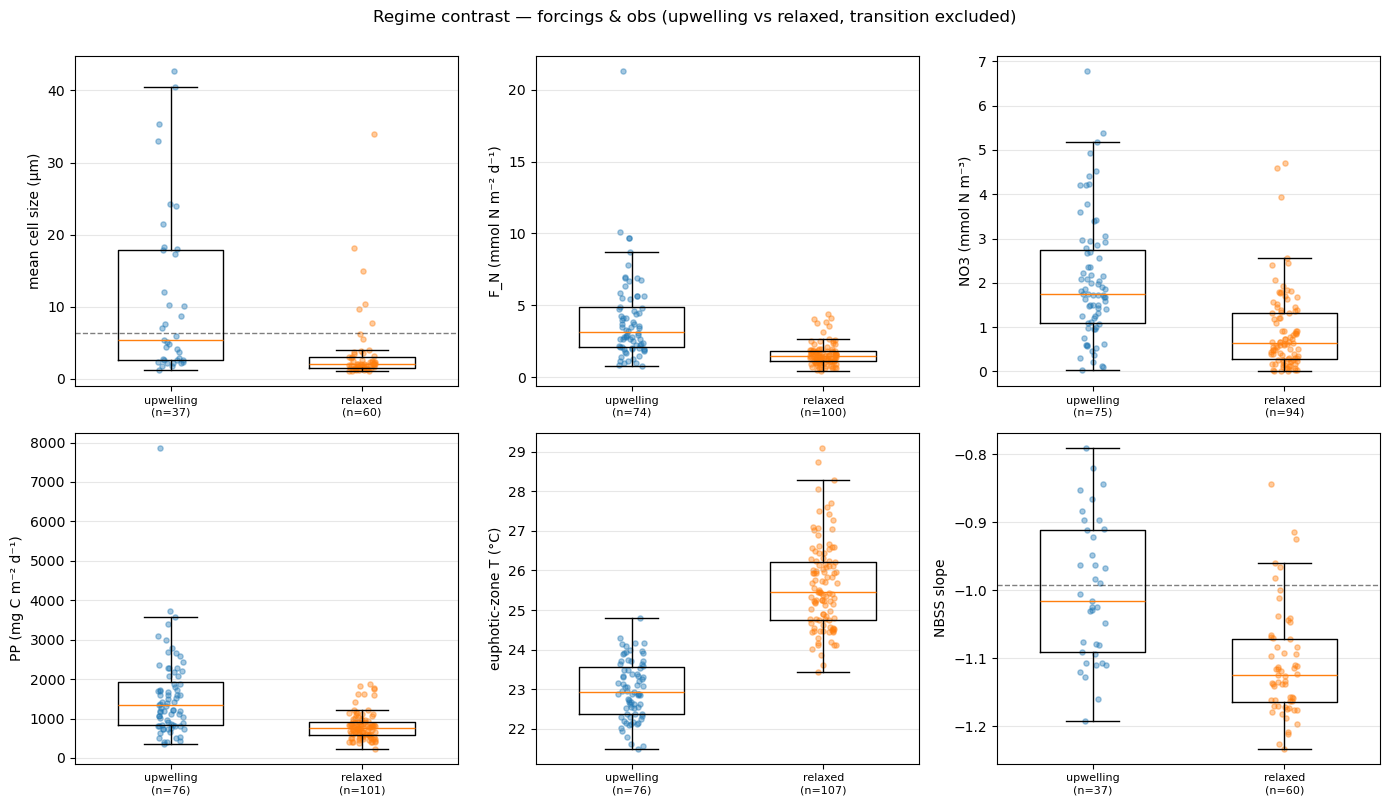

In [10]:
panels = [('mean_cell_um', 'mean cell size (µm)', 10**0.80),
          ('FN_mmolN_m2_d', 'F_N (mmol N m⁻² d⁻¹)', None),
          ('NO3_mmolN', 'NO3 (mmol N m⁻³)', None),
          ('PP_mgC_m2_d', 'PP (mg C m⁻² d⁻¹)', None),
          ('Temp_C', 'euphotic-zone T (°C)', None),
          ('nbss_slope', 'NBSS slope', -0.993)]
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for axx, (col, lab, ref) in zip(axes.flat, panels):
    gv = [d.loc[d.regime_adjusted == r, col].dropna().values for r in REG]
    boxstrip(axx, gv, [f"{r}\n(n={len(v)})" for r, v in zip(REG, gv)], neutral=ref)
    axx.set_ylabel(lab)
fig.suptitle('Regime contrast — forcings & obs (upwelling vs relaxed, transition excluded)', y=1.0)
fig.tight_layout(); plt.show()

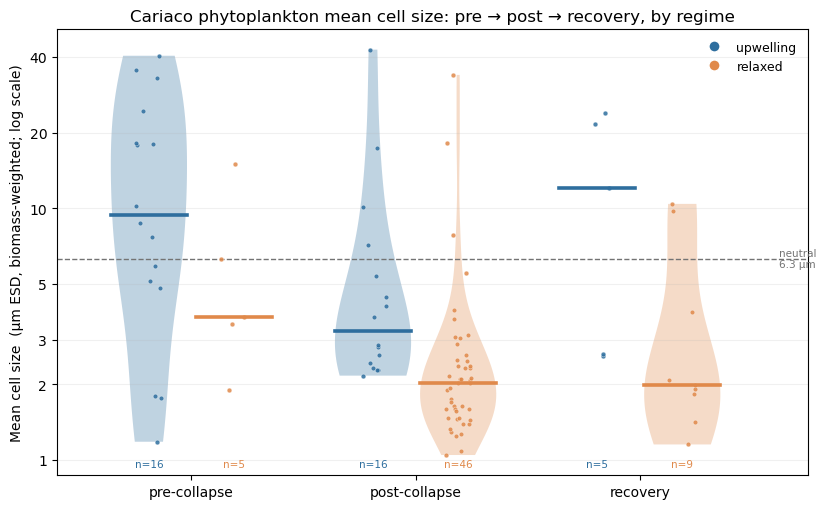

                          count  median
regime_adjusted era                    
relaxed         post         46   0.304
                pre           5   0.569
                recovery      9   0.297
upwelling       post         16   0.512
                pre          16   0.975
                recovery      5   1.082


In [11]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from cariaco_obs import DEFAULT_CSV_PATH

df = pd.read_csv(DEFAULT_CSV_PATH, parse_dates=['date'])
df = df.dropna(subset=['size_centroid'])
df = df[df['regime_adjusted'].isin(['upwelling', 'relaxed'])].copy()
df['era'] = np.where(df['date'].dt.year < 2005, 'pre',
            np.where(df['date'].dt.year < 2014, 'post', 'recovery'))

eras = ['pre', 'post', 'recovery']
era_lab = {'pre': 'pre-collapse', 'post': 'post-collapse', 'recovery': 'recovery'}
regimes = ['upwelling', 'relaxed']
col = {'upwelling': '#2E6E9E', 'relaxed': '#E0894A'}     # cool upwelling / warm relaxed
um_ticks = [1, 2, 3, 5, 10, 20, 40]                       # axis in µm, data in centroid space
NEUTRAL = 0.80                                            # centroid neutral = 6.3 µm
rng = np.random.default_rng(0)

fig, ax = plt.subplots(figsize=(8.4, 5.2))
for i, e in enumerate(eras):
    for r, dx in zip(regimes, (-0.19, 0.19)):
        v = df[(df.era == e) & (df.regime_adjusted == r)]['size_centroid'].values
        pos = i + dx
        if len(v) >= 6:                                  # only KDE where n supports it
            pc = ax.violinplot([v], positions=[pos], widths=0.34,
                               showmedians=False, showextrema=False)
            for b in pc['bodies']:
                b.set_facecolor(col[r]); b.set_edgecolor('none'); b.set_alpha(0.30)
        if len(v):
            ax.scatter(pos + (rng.random(len(v)) - .5) * 0.12, v, s=12, color=col[r],
                       edgecolor='white', linewidth=0.3, alpha=0.85, zorder=3)
            ax.plot([pos - 0.17, pos + 0.17], [np.median(v)] * 2, color=col[r], lw=2.6, zorder=4)
        ax.text(pos, 0.015, f'n={len(v)}', transform=ax.get_xaxis_transform(),
                ha='center', va='bottom', fontsize=7.5, color=col[r])

ax.axhline(NEUTRAL, color='0.45', ls='--', lw=1, zorder=1)
ax.text(2.62, NEUTRAL, 'neutral\n6.3 µm', va='center', ha='left', fontsize=7.5, color='0.45')
ax.set_yticks([np.log10(u) for u in um_ticks]); ax.set_yticklabels([str(u) for u in um_ticks])
ax.set_ylabel('Mean cell size  (µm ESD, biomass-weighted; log scale)')
ax.set_xticks(range(len(eras))); ax.set_xticklabels([era_lab[e] for e in eras])
ax.set_xlim(-0.6, 2.75)
ax.set_title('Cariaco phytoplankton mean cell size: pre → post → recovery, by regime')
ax.legend(handles=[Line2D([0], [0], marker='o', color='w', markerfacecolor=col[r],
                          markersize=8, label=r) for r in regimes],
          loc='upper right', frameon=False, fontsize=9)
ax.grid(axis='y', alpha=0.18)
plt.tight_layout(); plt.show()

print(df.groupby(['regime_adjusted', 'era'])['size_centroid'].agg(['count', 'median']).round(3))

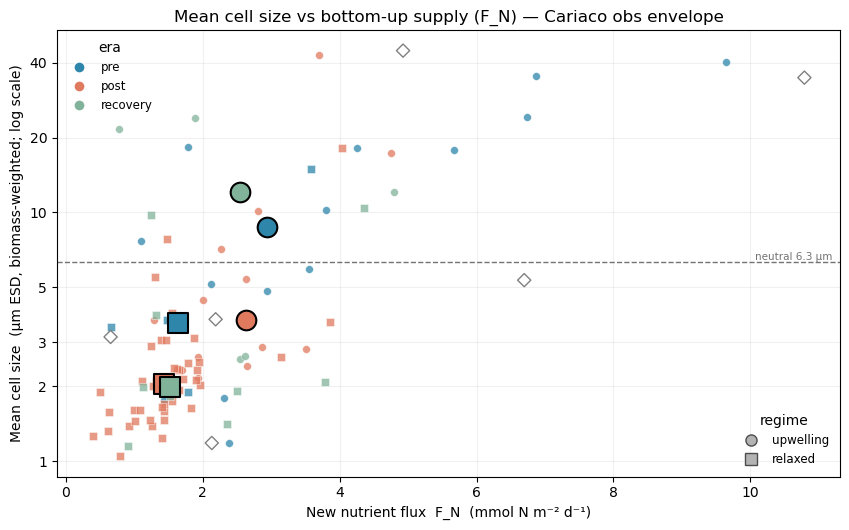

In [16]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from cariaco_obs import DEFAULT_CSV_PATH

df = pd.read_csv(DEFAULT_CSV_PATH, parse_dates=['date'])
df = df[df['regime_adjusted'].isin(['upwelling', 'relaxed'])].copy()
df['era'] = np.where(df['date'].dt.year < 2005, 'pre',
            np.where(df['date'].dt.year < 2014, 'post', 'recovery'))
sub = df.dropna(subset=['size_centroid', 'FN_mmolN_m2_d'])

era_col = {'pre': '#2E86AB', 'post': '#E07A5F', 'recovery': '#81B29A'}
reg_mk  = {'upwelling': 'o', 'relaxed': 's'}
um_ticks = [1, 2, 3, 5, 10, 20, 40]; NEUTRAL = 0.80

fig, ax = plt.subplots(figsize=(8.6, 5.4))
for e, c in era_col.items():
    for r, m in reg_mk.items():
        s = sub[(sub.era == e) & (sub.regime_adjusted == r)]
        ax.scatter(s.FN_mmolN_m2_d, s.size_centroid, c=c, marker=m, s=32,
                   edgecolor='white', linewidth=0.4, alpha=0.75, zorder=3)
        if len(s) >= 3:                                    # era×regime median anchor
            ax.scatter(s.FN_mmolN_m2_d.median(), s.size_centroid.median(), c=c, marker=m,
                       s=200, edgecolor='black', linewidth=1.5, zorder=5)
ax.axhline(NEUTRAL, color='0.45', ls='--', lw=1)
ax.text(0.99, NEUTRAL, 'neutral 6.3 µm', transform=ax.get_yaxis_transform(),
        ha='right', va='bottom', fontsize=7.5, color='0.45')
ax.set_yticks([np.log10(u) for u in um_ticks]); ax.set_yticklabels(um_ticks)
ax.set_ylabel('Mean cell size  (µm ESD, biomass-weighted; log scale)')
ax.set_xlabel('New nutrient flux  F_N  (mmol N m⁻² d⁻¹)')
ax.set_title('Mean cell size vs bottom-up supply (F_N) — Cariaco obs envelope')
leg1 = ax.legend(handles=[Line2D([0], [0], marker='o', color='w', markerfacecolor=c,
                  markersize=8, label=e) for e, c in era_col.items()],
                 title='era', loc='upper left', frameon=False, fontsize=8.5)
ax.add_artist(leg1)
ax.legend(handles=[Line2D([0], [0], marker=m, color='0.3', markerfacecolor='0.7',
          markersize=8, label=r, linestyle='') for r, m in reg_mk.items()],
          title='regime', loc='lower right', frameon=False, fontsize=8.5)
ax.grid(alpha=0.18)

# check transitional months:
t = pd.read_csv(DEFAULT_CSV_PATH, parse_dates=['date'])
t = t[t.regime_adjusted == 'transition'].dropna(subset=['size_centroid', 'FN_mmolN_m2_d'])
ax.scatter(t.FN_mmolN_m2_d, t.size_centroid, facecolor='none', edgecolor='0.5',
           marker='D', s=45, linewidth=1.0, label='transition', zorder=4)
plt.tight_layout(); plt.show()

In [17]:
import numpy as np, pandas as pd
from cariaco_obs import DEFAULT_CSV_PATH

d = pd.read_csv(DEFAULT_CSV_PATH, parse_dates=['date'])
d['era'] = np.where(d.date.dt.year < 2005, 'pre', np.where(d.date.dt.year < 2014, 'post', 'recovery'))
rr = d[d.regime_adjusted.isin(['upwelling', 'relaxed'])].copy()
s1 = rr.dropna(subset=['size_centroid', 'FN_mmolN_m2_d']).copy()
s1['mean_cell_um'] = 10**s1.size_centroid

print("PLOT 1 — size & F_N by era × regime")
print(s1.groupby(['regime_adjusted', 'era']).agg(
    n=('size_centroid', 'size'), cell_um_med=('mean_cell_um', 'median'),
    FN_med=('FN_mmolN_m2_d', 'median'),
    FN_q90=('FN_mmolN_m2_d', lambda x: x.quantile(.9)),
    FN_max=('FN_mmolN_m2_d', 'max')).round(2))

print("\nsize_centroid ~ F_N (Spearman):")
for lab, s in [('all', s1), ('upwelling', s1[s1.regime_adjusted == 'upwelling']),
               ('relaxed', s1[s1.regime_adjusted == 'relaxed'])]:
    print(f"  {lab:10s} n={len(s):3d}  rho={s.size_centroid.corr(s.FN_mmolN_m2_d, method='spearman'):+.2f}")

print("\nWhy are the highest F_N months pre? — era drivers")
print(rr.dropna(subset=['FN_mmolN_m2_d']).groupby('era').agg(
    n=('FN_mmolN_m2_d', 'size'), FN_med=('FN_mmolN_m2_d', 'median'), FN_max=('FN_mmolN_m2_d', 'max'),
    PP_med=('PP_mgC_m2_d', 'median'), Iso21_med=('Isotherm_21', 'median'),
    NO3_med=('NO3_mmolN', 'median'), temp50_med=('temp_50m', 'median')).round(1))

print("\nTop-8 F_N months (genuine upwelling = shallow Iso21 + high NO3?):")
print(rr.nlargest(8, 'FN_mmolN_m2_d')[['date', 'era', 'regime_adjusted', 'FN_mmolN_m2_d',
      'PP_mgC_m2_d', 'Isotherm_21', 'NO3_mmolN', 'temp_50m']].to_string(index=False))

print("\nF_N ~ driver (Spearman, all u/r months):")
fn = rr.dropna(subset=['FN_mmolN_m2_d'])
for c in ['PP_mgC_m2_d', 'Isotherm_21', 'NO3_mmolN', 'temp_50m']:
    ss = fn.dropna(subset=[c])
    print(f"  F_N ~ {c:14s} rho={ss.FN_mmolN_m2_d.corr(ss[c], method='spearman'):+.2f} (n={len(ss)})")

PLOT 1 — size & F_N by era × regime
                           n  cell_um_med  FN_med  FN_q90  FN_max
regime_adjusted era                                              
relaxed         post      42         2.05    1.43    1.94    4.04
                pre        4         3.58    1.63    3.04    3.57
                recovery   9         1.98    1.53    3.90    4.36
upwelling       post      13         3.69    2.63    3.65    4.75
                pre       15         8.73    2.94    6.82    9.65
                recovery   5        12.09    2.54    3.93    4.80

size_centroid ~ F_N (Spearman):
  all        n= 88  rho=+0.58
  upwelling  n= 33  rho=+0.47
  relaxed    n= 55  rho=+0.47

Why are the highest F_N months pre? — era drivers
           n  FN_med  FN_max  PP_med  Iso21_med  NO3_med  temp50_med
era                                                                 
post      77     1.7     8.7   816.1      107.0      0.9        23.1
pre       80     2.1    21.3   918.7       90.5      1.

In [20]:
# incldue transitional months
import numpy as np, pandas as pd
from cariaco_obs import DEFAULT_CSV_PATH

d = pd.read_csv(DEFAULT_CSV_PATH, parse_dates=['date'])
d['mean_cell_um'] = 10**d['size_centroid']

tr = d[(d.regime_adjusted == 'transition') & d.size_centroid.notna()][
     ['date', 'boundary_adj', 'FN_mmolN_m2_d', 'NO3_mmolN', 'mean_cell_um']].sort_values('date')
print("Transition months with size data:")
print(tr.round(2).to_string(index=False))

def medians(df, label):
    sub = df[df.regime_adjusted.isin(['upwelling', 'relaxed'])]
    g = sub.groupby('regime_adjusted')[['mean_cell_um', 'FN_mmolN_m2_d', 'NO3_mmolN']].median().round(2)
    g['n'] = sub.groupby('regime_adjusted').size()
    print(f"\n[{label}]"); print(g)

medians(d, "canonical (transition excluded)")
up = d.copy(); up.loc[up.regime_adjusted == 'transition', 'regime_adjusted'] = 'upwelling'
medians(up, "transition -> upwelling (defensible sensitivity)")
rl = d.copy(); rl.loc[rl.regime_adjusted == 'transition', 'regime_adjusted'] = 'relaxed'
medians(rl, "transition -> relaxed")

Transition months with size data:
      date boundary_adj  FN_mmolN_m2_d  NO3_mmolN  mean_cell_um
1997-01-01      leading          10.79       2.37         34.81
1997-06-01         both           2.13       1.70          1.18
1998-04-01     trailing           0.65       1.38          3.16
2000-01-01      leading           6.70       1.41          5.34
2011-05-01     trailing           2.19       1.63          3.71
2012-01-01      leading           4.92       0.30         44.71

[canonical (transition excluded)]
                 mean_cell_um  FN_mmolN_m2_d  NO3_mmolN    n
regime_adjusted                                             
relaxed                  2.04           1.44       0.63  127
upwelling                5.40           3.15       1.76   87

[transition -> upwelling (defensible sensitivity)]
                 mean_cell_um  FN_mmolN_m2_d  NO3_mmolN    n
regime_adjusted                                             
relaxed                  2.04           1.44       0.63  127
upwe

/var/folders/98/6c9k3fxx2hl5k0_928yjt7qw0000gn/T/ipykernel_5567/582395809.py:11: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(tr.round(2).to_string(index=False))


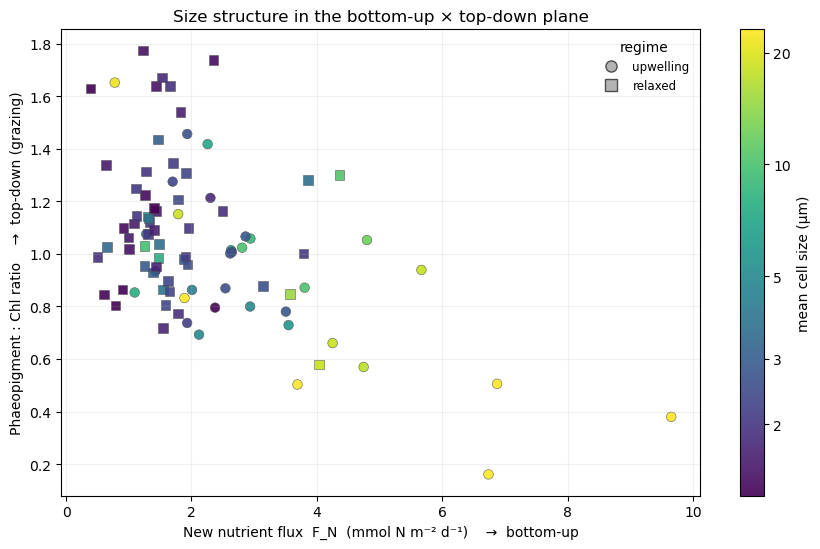

n in plane: 88 | by regime: {'relaxed': 55, 'upwelling': 33}


In [13]:
sub2 = df.dropna(subset=['FN_mmolN_m2_d', 'PhaeoChl_ratio', 'size_centroid'])

fig, ax = plt.subplots(figsize=(8.8, 5.6))
norm = plt.Normalize(sub2.size_centroid.quantile(.05), sub2.size_centroid.quantile(.95))
for r, m in reg_mk.items():
    s = sub2[sub2.regime_adjusted == r]
    sc = ax.scatter(s.FN_mmolN_m2_d, s.PhaeoChl_ratio, c=s.size_centroid, cmap='viridis',
                    norm=norm, marker=m, s=48, edgecolor='0.3', linewidth=0.4, alpha=0.9)
cb = fig.colorbar(sc, ax=ax)
cb.set_label('mean cell size (µm)')
cb.set_ticks([np.log10(u) for u in [2, 3, 5, 10, 20]]); cb.set_ticklabels(['2', '3', '5', '10', '20'])
ax.set_xlabel('New nutrient flux  F_N  (mmol N m⁻² d⁻¹)    →  bottom-up')
ax.set_ylabel('Phaeopigment : Chl ratio    →  top-down (grazing)')
ax.set_title('Size structure in the bottom-up × top-down plane')
ax.legend(handles=[Line2D([0], [0], marker=m, color='0.3', markerfacecolor='0.7',
          markersize=8, label=r, linestyle='') for r, m in reg_mk.items()],
          title='regime', loc='best', frameon=False, fontsize=8.5)
ax.grid(alpha=0.18)
plt.tight_layout(); plt.show()
print('n in plane:', len(sub2), '| by regime:', sub2.regime_adjusted.value_counts().to_dict())

In [18]:
s2 = rr.dropna(subset=['FN_mmolN_m2_d', 'PhaeoChl_ratio', 'size_centroid']).copy()
s2['mean_cell_um'] = 10**s2.size_centroid
print(f"PLOT 2 — bottom-up × top-down | n={len(s2)} | {s2.regime_adjusted.value_counts().to_dict()}")
print("\nSpearman:")
for a, b in [('size_centroid', 'FN_mmolN_m2_d'), ('size_centroid', 'PhaeoChl_ratio'),
             ('FN_mmolN_m2_d', 'PhaeoChl_ratio')]:
    print(f"  {a} ~ {b}: rho={s2[a].corr(s2[b], method='spearman'):+.2f}")
print("\nTop-5 PhaeoChl:Chl months (the outlier hunt):")
print(s2.nlargest(5, 'PhaeoChl_ratio')[['date', 'era', 'regime_adjusted', 'PhaeoChl_ratio',
      'FN_mmolN_m2_d', 'mean_cell_um']].round(2).to_string(index=False))

PLOT 2 — bottom-up × top-down | n=88 | {'relaxed': 55, 'upwelling': 33}

Spearman:
  size_centroid ~ FN_mmolN_m2_d: rho=+0.58
  size_centroid ~ PhaeoChl_ratio: rho=-0.37
  FN_mmolN_m2_d ~ PhaeoChl_ratio: rho=-0.37

Top-5 PhaeoChl:Chl months (the outlier hunt):
      date      era regime_adjusted  PhaeoChl_ratio  FN_mmolN_m2_d  mean_cell_um
2013-12-01     post         relaxed            1.77           1.22          1.46
2014-11-01 recovery         relaxed            1.74           2.35          1.41
2014-10-01 recovery         relaxed            1.67           1.53          1.82
2015-03-01 recovery       upwelling            1.65           0.78         21.54
2011-10-01     post         relaxed            1.64           1.44          1.47


/var/folders/98/6c9k3fxx2hl5k0_928yjt7qw0000gn/T/ipykernel_5567/2794326793.py:10: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  'FN_mmolN_m2_d', 'mean_cell_um']].round(2).to_string(index=False))


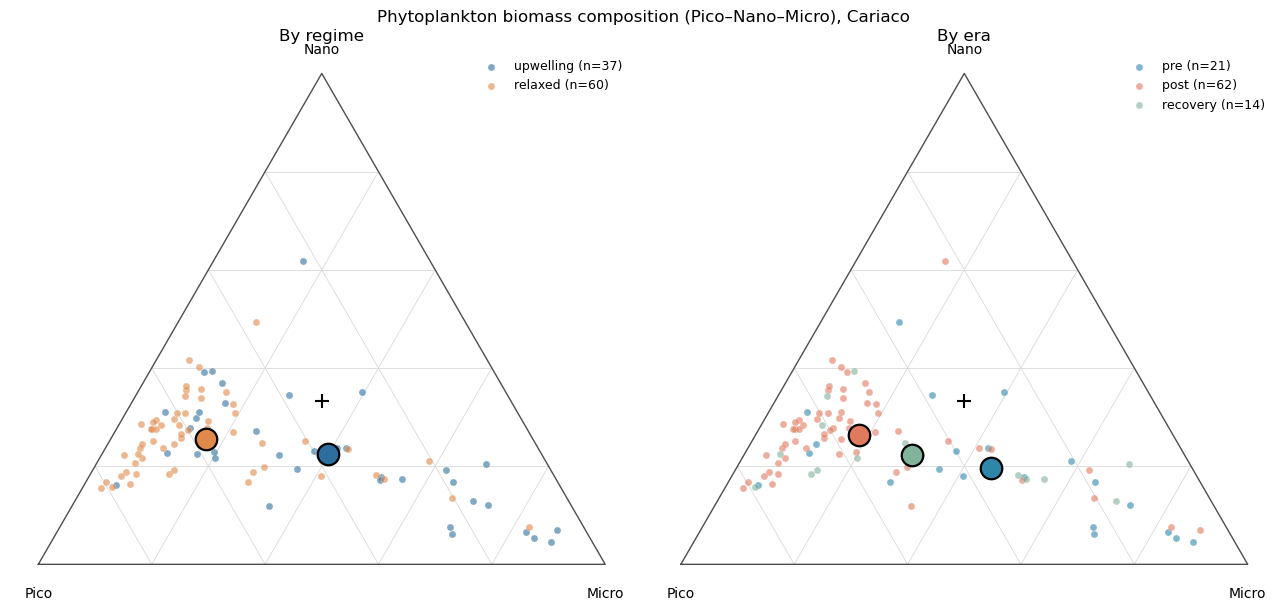

Mean composition by regime:
                 pico_frac_N  nano_frac_N  micro_frac_N
regime_adjusted                                        
relaxed                0.577        0.255         0.168
upwelling              0.377        0.224         0.400

Mean composition by era:
          pico_frac_N  nano_frac_N  micro_frac_N
era                                             
post            0.554        0.264         0.182
pre             0.355        0.196         0.449
recovery        0.482        0.222         0.296


In [21]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from cariaco_obs import DEFAULT_CSV_PATH

df = pd.read_csv(DEFAULT_CSV_PATH, parse_dates=['date'])
df = (df[df.regime_adjusted.isin(['upwelling', 'relaxed'])]
      .dropna(subset=['micro_frac_N', 'nano_frac_N', 'pico_frac_N']).copy())
df['era'] = np.where(df.date.dt.year < 2005, 'pre', np.where(df.date.dt.year < 2014, 'post', 'recovery'))

h = np.sqrt(3) / 2
def tern(p_pico, p_nano, p_micro):           # barycentric -> 2D
    return 0.5 * p_nano + p_micro, h * p_nano

def draw_triangle(ax):
    tri = np.array([tern(1, 0, 0), tern(0, 0, 1), tern(0, 1, 0), tern(1, 0, 0)])
    ax.plot(tri[:, 0], tri[:, 1], color='0.3', lw=1)
    for f in np.arange(0.2, 1.0, 0.2):
        ax.plot(*zip(tern(1 - f, 0, f), tern(0, 1 - f, f)), color='0.85', lw=0.6, zorder=0)
        ax.plot(*zip(tern(f, 1 - f, 0), tern(f, 0, 1 - f)), color='0.85', lw=0.6, zorder=0)
        ax.plot(*zip(tern(0, f, 1 - f), tern(1 - f, f, 0)), color='0.85', lw=0.6, zorder=0)
    ax.text(0, -0.04, 'Pico', ha='center', va='top', fontsize=10)
    ax.text(1, -0.04, 'Micro', ha='center', va='top', fontsize=10)
    ax.text(0.5, h + 0.03, 'Nano', ha='center', va='bottom', fontsize=10)
    nx, ny = tern(1/3, 1/3, 1/3); ax.scatter([nx], [ny], marker='+', s=90, color='k', zorder=5)
    ax.set_aspect('equal'); ax.axis('off')

df['tx'], df['ty'] = tern(df.pico_frac_N.values, df.nano_frac_N.values, df.micro_frac_N.values)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
groupings = [('regime_adjusted', {'upwelling': '#2E6E9E', 'relaxed': '#E0894A'}, 'By regime'),
             ('era', {'pre': '#2E86AB', 'post': '#E07A5F', 'recovery': '#81B29A'}, 'By era')]
for ax, (gcol, cmap, title) in zip(axes, groupings):
    draw_triangle(ax)
    for g, c in cmap.items():
        s = df[df[gcol] == g]
        ax.scatter(s.tx, s.ty, c=c, s=26, alpha=0.6, edgecolor='white', linewidth=0.3, label=f'{g} (n={len(s)})')
        mx, my = tern(s.pico_frac_N.mean(), s.nano_frac_N.mean(), s.micro_frac_N.mean())
        ax.scatter([mx], [my], c=c, s=240, edgecolor='black', linewidth=1.6, zorder=6)
    ax.set_title(title); ax.legend(loc='upper right', frameon=False, fontsize=9)
fig.suptitle('Phytoplankton biomass composition (Pico–Nano–Micro), Cariaco', y=0.99)
plt.tight_layout(); plt.show()

print("Mean composition by regime:")
print(df.groupby('regime_adjusted')[['pico_frac_N', 'nano_frac_N', 'micro_frac_N']].mean().round(3))
print("\nMean composition by era:")
print(df.groupby('era')[['pico_frac_N', 'nano_frac_N', 'micro_frac_N']].mean().round(3))

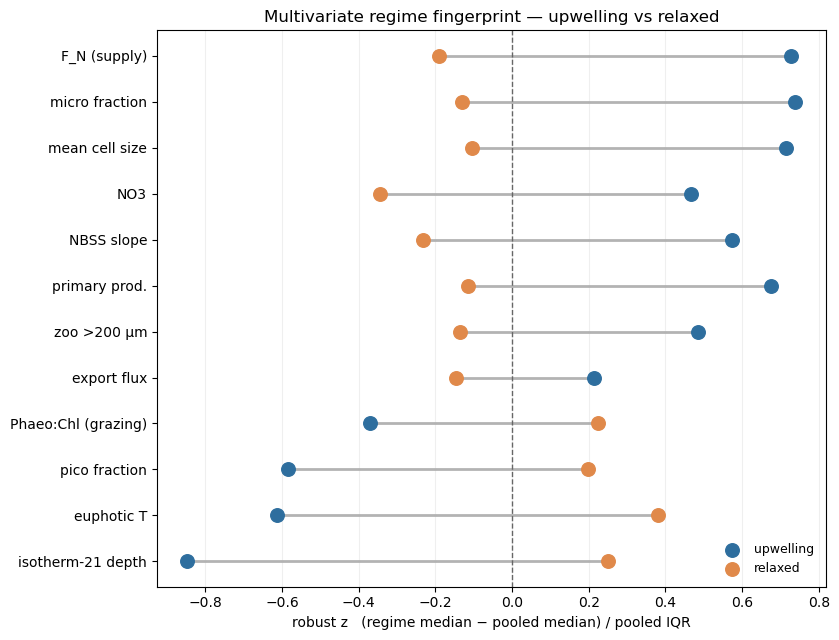

             metric  z_up  z_rel   gap
  isotherm-21 depth -0.85   0.25 -1.10
         euphotic T -0.61   0.38 -0.99
      pico fraction -0.58   0.20 -0.78
Phaeo:Chl (grazing) -0.37   0.22 -0.59
        export flux  0.21  -0.14  0.36
        zoo >200 µm  0.49  -0.14  0.62
      primary prod.  0.68  -0.11  0.79
         NBSS slope  0.57  -0.23  0.81
                NO3  0.47  -0.35  0.81
     mean cell size  0.71  -0.10  0.82
     micro fraction  0.74  -0.13  0.87
       F_N (supply)  0.73  -0.19  0.92


In [22]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from cariaco_obs import DEFAULT_CSV_PATH

df = pd.read_csv(DEFAULT_CSV_PATH, parse_dates=['date'])
df = df[df.regime_adjusted.isin(['upwelling', 'relaxed'])].copy()
df['mean_cell_um'] = 10**df['size_centroid']

metrics = [('mean_cell_um', 'mean cell size'), ('nbss_slope', 'NBSS slope'),
           ('micro_frac_N', 'micro fraction'), ('pico_frac_N', 'pico fraction'),
           ('FN_mmolN_m2_d', 'F_N (supply)'), ('NO3_mmolN', 'NO3'),
           ('PP_mgC_m2_d', 'primary prod.'), ('Temp_C', 'euphotic T'),
           ('Isotherm_21', 'isotherm-21 depth'), ('PhaeoChl_ratio', 'Phaeo:Chl (grazing)'),
           ('zoo_gt200_mmolN', 'zoo >200 µm'), ('export_flux_corrected_mmolN', 'export flux')]

rows = []
for col, lab in metrics:
    if col not in df.columns: continue
    s = df[col].dropna(); iqr = s.quantile(.75) - s.quantile(.25)
    if iqr == 0 or np.isnan(iqr): continue
    med = s.median()
    z = lambda r: (df.loc[df.regime_adjusted == r, col].median() - med) / iqr
    rows.append((lab, z('upwelling'), z('relaxed')))
fp = pd.DataFrame(rows, columns=['metric', 'z_up', 'z_rel'])
fp['gap'] = fp.z_up - fp.z_rel
fp = fp.sort_values('gap')

fig, ax = plt.subplots(figsize=(8.5, 6.5))
y = np.arange(len(fp))
ax.hlines(y, fp.z_rel, fp.z_up, color='0.7', lw=2, zorder=1)
ax.scatter(fp.z_up, y, color='#2E6E9E', s=95, zorder=3, label='upwelling')
ax.scatter(fp.z_rel, y, color='#E0894A', s=95, zorder=3, label='relaxed')
ax.axvline(0, color='0.4', ls='--', lw=1)
ax.set_yticks(y); ax.set_yticklabels(fp.metric)
ax.set_xlabel('robust z   (regime median − pooled median) / pooled IQR')
ax.set_title('Multivariate regime fingerprint — upwelling vs relaxed')
ax.legend(loc='lower right', frameon=False, fontsize=9)
ax.grid(axis='x', alpha=0.2)
plt.tight_layout(); plt.show()
print(fp.round(2).to_string(index=False))

Raw era medians within upwelling:
             metric     pre    post  recovery
     mean cell size    9.46    3.28     12.09
         NBSS slope   -0.97   -1.06     -0.95
     micro fraction    0.47    0.18      0.55
      pico fraction    0.28    0.50      0.27
       F_N (supply)    3.42    2.81      3.05
                NO3    1.59    2.00      1.62
      primary prod. 1408.62 1188.14   1209.97
         euphotic T   23.09   22.94     22.74
  isotherm-21 depth   56.50   55.00     56.00
Phaeo:Chl (grazing)    0.76    1.01      0.92
        zoo >200 µm    0.06    0.09      0.06
        export flux    3.17    3.02       NaN


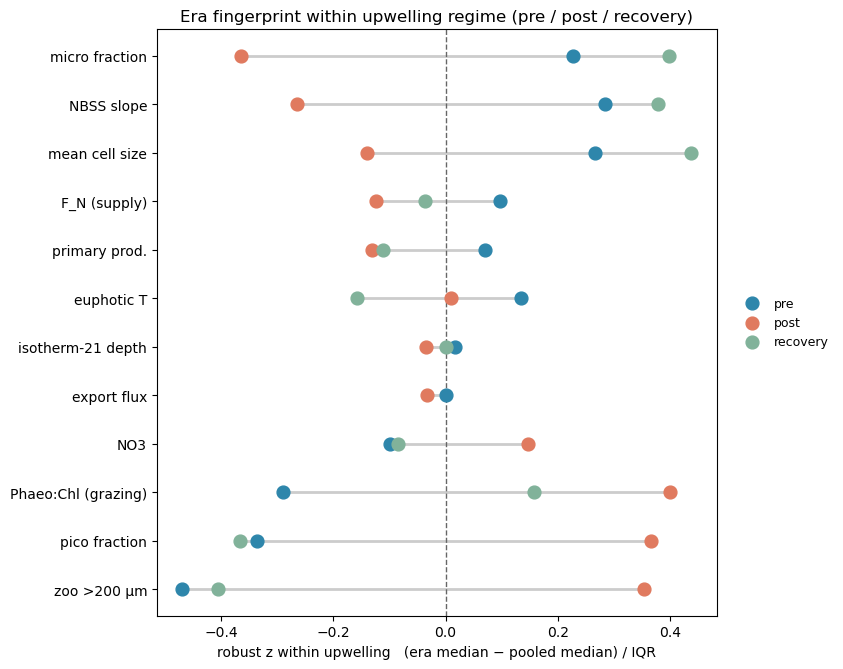

In [24]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from cariaco_obs import DEFAULT_CSV_PATH

REGIME = 'upwelling'   # 'upwelling' (best pre/post balance) | 'relaxed' | 'all' (confounded)

df = pd.read_csv(DEFAULT_CSV_PATH, parse_dates=['date'])
df = df[df.regime_adjusted.isin(['upwelling', 'relaxed'])].copy()
df['mean_cell_um'] = 10**df['size_centroid']
df['era'] = np.where(df.date.dt.year < 2005, 'pre', np.where(df.date.dt.year < 2014, 'post', 'recovery'))
if REGIME != 'all':
    df = df[df.regime_adjusted == REGIME]

metrics = [('mean_cell_um', 'mean cell size'), ('nbss_slope', 'NBSS slope'),
           ('micro_frac_N', 'micro fraction'), ('pico_frac_N', 'pico fraction'),
           ('FN_mmolN_m2_d', 'F_N (supply)'), ('NO3_mmolN', 'NO3'),
           ('PP_mgC_m2_d', 'primary prod.'), ('Temp_C', 'euphotic T'),
           ('Isotherm_21', 'isotherm-21 depth'), ('PhaeoChl_ratio', 'Phaeo:Chl (grazing)'),
           ('zoo_gt200_mmolN', 'zoo >200 µm'), ('export_flux_corrected_mmolN', 'export flux')]
eras = ['pre', 'post', 'recovery']; ecol = {'pre': '#2E86AB', 'post': '#E07A5F', 'recovery': '#81B29A'}

rows, raw = [], []
for col, lab in metrics:
    if col not in df.columns: continue
    s = df[col].dropna(); iqr = s.quantile(.75) - s.quantile(.25)
    if iqr == 0 or np.isnan(iqr): continue
    med = s.median()
    rows.append((lab, *[(df.loc[df.era == e, col].median() - med) / iqr for e in eras]))
    raw.append((lab, *[round(df.loc[df.era == e, col].median(), 2) for e in eras]))
fp = pd.DataFrame(rows, columns=['metric', *eras])
fp['gap'] = fp['pre'] - fp['post']; fp = fp.sort_values('gap')

fig, ax = plt.subplots(figsize=(8.8, 6.8)); y = np.arange(len(fp))
ax.hlines(y, fp[eras].min(axis=1), fp[eras].max(axis=1), color='0.8', lw=2, zorder=1)
for e in eras:
    ax.scatter(fp[e], y, color=ecol[e], s=85, zorder=3, label=e)
ax.axvline(0, color='0.4', ls='--', lw=1)
ax.set_yticks(y); ax.set_yticklabels(fp.metric)
ax.set_xlabel(f'robust z within {REGIME}   (era median − pooled median) / IQR')
ax.set_title(f'Era fingerprint within {REGIME} regime (pre / post / recovery)')
#ax.legend(loc='lower right', frameon=False, fontsize=9); ax.grid(axis='x', alpha=0.2)
#plt.tight_layout(); plt.show()

ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False, fontsize=9)
fig.tight_layout(); fig.subplots_adjust(right=0.82)

print(f"Raw era medians within {REGIME}:")
print(pd.DataFrame(raw, columns=['metric', *eras]).to_string(index=False))

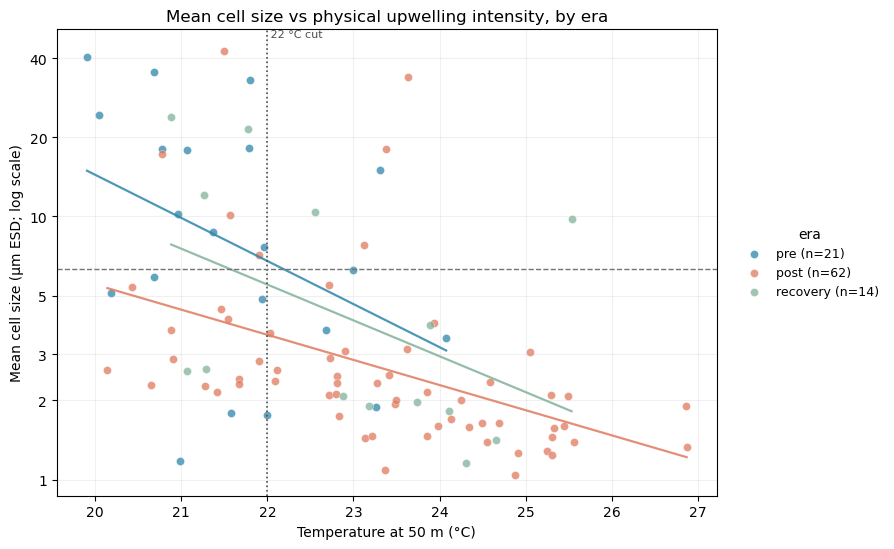

Spearman size_centroid ~ temp_50m:
  all       n= 97  rho=-0.61
  pre       n= 21  rho=-0.46
  post      n= 62  rho=-0.65
  recovery  n= 14  rho=-0.62


In [25]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from cariaco_obs import DEFAULT_CSV_PATH

XCOL, XLAB, XTHRESH = 'temp_50m', 'Temperature at 50 m (°C)', 22.0   # or 'Isotherm_21', 'Isotherm-21 depth (m)', None

df = pd.read_csv(DEFAULT_CSV_PATH, parse_dates=['date'])
df = df[df.regime_adjusted.isin(['upwelling', 'relaxed'])].dropna(subset=['size_centroid', XCOL]).copy()
df['era'] = np.where(df.date.dt.year < 2005, 'pre', np.where(df.date.dt.year < 2014, 'post', 'recovery'))
ecol = {'pre': '#2E86AB', 'post': '#E07A5F', 'recovery': '#81B29A'}
um_ticks = [1, 2, 3, 5, 10, 20, 40]; NEUTRAL = 0.80

fig, ax = plt.subplots(figsize=(8.8, 5.6))
for e, c in ecol.items():
    s = df[df.era == e]
    ax.scatter(s[XCOL], s.size_centroid, c=c, s=34, alpha=0.75, edgecolor='white',
               linewidth=0.3, label=f'{e} (n={len(s)})')
    if len(s) >= 8:                                       # light guide-the-eye trend
        b = np.polyfit(s[XCOL], s.size_centroid, 1); xx = np.linspace(s[XCOL].min(), s[XCOL].max(), 50)
        ax.plot(xx, np.polyval(b, xx), color=c, lw=1.6, alpha=0.85)
if XTHRESH is not None:
    ax.axvline(XTHRESH, color='0.3', ls=':', lw=1.2)
    ax.text(XTHRESH, ax.get_ylim()[1], f' {XTHRESH:.0f} °C cut', va='top', fontsize=8, color='0.3')
ax.axhline(NEUTRAL, color='0.45', ls='--', lw=1)
ax.set_yticks([np.log10(u) for u in um_ticks]); ax.set_yticklabels(um_ticks)
ax.set_ylabel('Mean cell size (µm ESD; log scale)'); ax.set_xlabel(XLAB)
ax.set_title('Mean cell size vs physical upwelling intensity, by era')
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False, fontsize=9, title='era')
ax.grid(alpha=0.18); fig.tight_layout(); fig.subplots_adjust(right=0.82)
plt.show()

print(f"Spearman size_centroid ~ {XCOL}:")
for lab, s in [('all', df)] + [(e, df[df.era == e]) for e in ecol]:
    print(f"  {lab:9s} n={len(s):3d}  rho={s.size_centroid.corr(s[XCOL], method='spearman'):+.2f}")

In [26]:
import numpy as np, pandas as pd
from cariaco_obs import DEFAULT_CSV_PATH

d = pd.read_csv(DEFAULT_CSV_PATH, parse_dates=['date'])
d = d[d.regime_adjusted.isin(['upwelling', 'relaxed'])].dropna(subset=['size_centroid', 'temp_50m']).copy()
d['moy'] = d.date.dt.month
for c in ['size_centroid', 'temp_50m']:
    d[c + '_anom'] = d[c] - d.groupby('moy')[c].transform('mean')

print("size_centroid ~ temp_50m (Spearman):")
print(f"  raw         rho={d.size_centroid.corr(d.temp_50m, method='spearman'):+.2f}  (n={len(d)})")
print(f"  deseasoned  rho={d.size_centroid_anom.corr(d.temp_50m_anom, method='spearman'):+.2f}")
print(f"  month-of-year explains "
      f"{100*(1 - d.size_centroid_anom.var(ddof=0)/d.size_centroid.var(ddof=0)):.0f}% of size variance")

size_centroid ~ temp_50m (Spearman):
  raw         rho=-0.61  (n=97)
  deseasoned  rho=-0.34
  month-of-year explains 47% of size variance


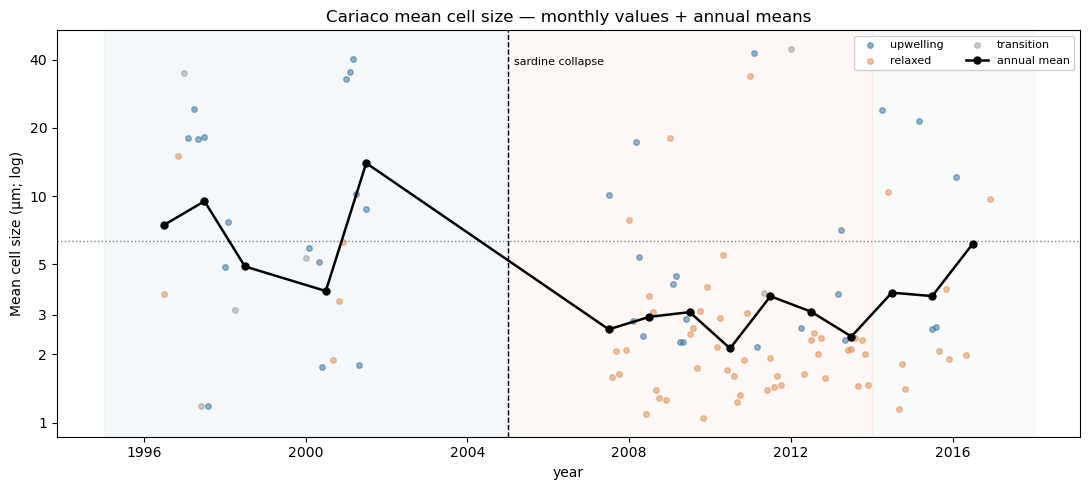

 year   cen  n
 1996 0.873  2
 1997 0.977  7
 1998 0.689  3
 2000 0.581  7
 2001 1.146  6
 2007 0.411  5
 2008 0.467 11
 2009 0.488 12
 2010 0.327  9
 2011 0.558  9
 2012 0.490  8
 2013 0.380 10
 2014 0.574  5
 2015 0.558  6
 2016 0.789  3


In [27]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from cariaco_obs import DEFAULT_CSV_PATH

d = pd.read_csv(DEFAULT_CSV_PATH, parse_dates=['date']).dropna(subset=['size_centroid']).copy()
d['year'] = d.date.dt.year
ann = d.groupby('year').agg(cen=('size_centroid', 'mean'), n=('size_centroid', 'size')).reset_index()

reg_col = {'upwelling': '#2E6E9E', 'relaxed': '#E0894A', 'transition': '0.6'}
fig, ax = plt.subplots(figsize=(11, 5))
for x0, x1, c in [('1995', '2005', '#2E86AB'), ('2005', '2014', '#E07A5F'), ('2014', '2018', '#81B29A')]:
    ax.axvspan(pd.Timestamp(x0), pd.Timestamp(x1), color=c, alpha=0.05)
ax.axvline(pd.Timestamp('2005-01-01'), color='k', ls='--', lw=1)
ax.text(pd.Timestamp('2005-03-01'), np.log10(38), 'sardine collapse', fontsize=8)
for r, c in reg_col.items():
    s = d[d.regime_adjusted == r]
    ax.scatter(s.date, s.size_centroid, c=c, s=16, alpha=0.5, label=r, zorder=2)
ax.plot(pd.to_datetime(ann.year.astype(str) + '-07-01'), ann.cen, '-o', color='black',
        lw=1.8, ms=5, zorder=4, label='annual mean')
ax.axhline(0.80, color='0.5', ls=':', lw=1)
ax.set_yticks([np.log10(u) for u in [1, 2, 3, 5, 10, 20, 40]]); ax.set_yticklabels([1, 2, 3, 5, 10, 20, 40])
ax.set_ylabel('Mean cell size (µm; log)'); ax.set_xlabel('year')
ax.set_title('Cariaco mean cell size — monthly values + annual means')
ax.legend(loc='upper right', fontsize=8, ncol=2, framealpha=0.9)
plt.tight_layout(); plt.show()
print(ann.round(3).to_string(index=False))

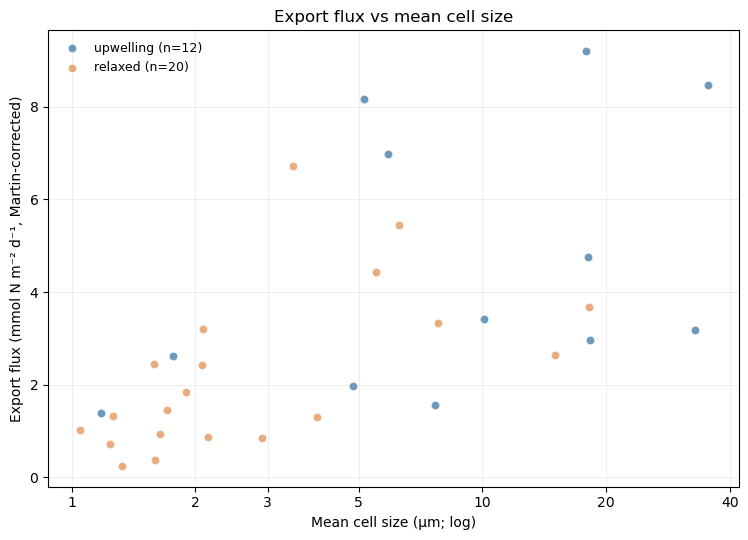

Spearman export ~ size_centroid: 0.71 | n = 32


In [28]:
d2 = (pd.read_csv(DEFAULT_CSV_PATH, parse_dates=['date'])
      .dropna(subset=['export_flux_corrected_mmolN', 'size_centroid']))
d2 = d2[d2.regime_adjusted.isin(['upwelling', 'relaxed'])]
fig, ax = plt.subplots(figsize=(7.6, 5.5))
for r, c in [('upwelling', '#2E6E9E'), ('relaxed', '#E0894A')]:
    s = d2[d2.regime_adjusted == r]
    ax.scatter(s.size_centroid, s.export_flux_corrected_mmolN, c=c, s=34, alpha=0.7,
               edgecolor='white', linewidth=0.3, label=f'{r} (n={len(s)})')
ax.set_xticks([np.log10(u) for u in [1, 2, 3, 5, 10, 20, 40]]); ax.set_xticklabels([1, 2, 3, 5, 10, 20, 40])
ax.set_xlabel('Mean cell size (µm; log)'); ax.set_ylabel('Export flux (mmol N m⁻² d⁻¹, Martin-corrected)')
ax.set_title('Export flux vs mean cell size')
ax.legend(frameon=False, fontsize=9); ax.grid(alpha=0.2)
plt.tight_layout(); plt.show()
print("Spearman export ~ size_centroid:",
      round(d2.export_flux_corrected_mmolN.corr(d2.size_centroid, method='spearman'), 2), "| n =", len(d2))

In [29]:
import numpy as np, pandas as pd
from cariaco_obs import DEFAULT_CSV_PATH

d = pd.read_csv(DEFAULT_CSV_PATH, parse_dates=['date'])
d = d[d.regime_adjusted.isin(['upwelling', 'relaxed'])].copy()
d['mean_cell_um'] = 10**d['size_centroid']

print("1. Export by regime (raw 225 m vs Martin-corrected) — median [n]:")
for col in ['export_flux_mmolN', 'export_flux_corrected_mmolN']:
    g = d.groupby('regime_adjusted')[col].agg(['median', 'count']).round(2)
    print(f"  {col}:\n{g}")

e = d.dropna(subset=['export_flux_corrected_mmolN', 'size_centroid'])
print(f"\n2. export∩size subset: n={len(e)} | by regime {e.regime_adjusted.value_counts().to_dict()}")
print(e.groupby('regime_adjusted')[['mean_cell_um', 'export_flux_corrected_mmolN', 'FN_mmolN_m2_d']].median().round(2))

print("\n3. export_corrected ~ size_centroid Spearman (overall vs within regime):")
for lab, s in [('all', e), ('upwelling', e[e.regime_adjusted == 'upwelling']),
               ('relaxed', e[e.regime_adjusted == 'relaxed'])]:
    if len(s) > 3:
        print(f"  {lab:10s} n={len(s):2d}  rho={s.export_flux_corrected_mmolN.corr(s.size_centroid, method='spearman'):+.2f}")

print("\n4. what drives export (all export months) — Spearman:")
for c in ['FN_mmolN_m2_d', 'PP_mgC_m2_d', 'size_centroid', 'depth_cutoff']:
    s = d.dropna(subset=['export_flux_corrected_mmolN', c])
    print(f"  export ~ {c:14s} rho={s.export_flux_corrected_mmolN.corr(s[c], method='spearman'):+.2f} (n={len(s)})")

1. Export by regime (raw 225 m vs Martin-corrected) — median [n]:
  export_flux_mmolN:
                 median  count
regime_adjusted               
relaxed            0.61     76
upwelling          0.71     47
  export_flux_corrected_mmolN:
                 median  count
regime_adjusted               
relaxed            2.23     63
upwelling          3.17     41

2. export∩size subset: n=32 | by regime {'relaxed': 20, 'upwelling': 12}
                 mean_cell_um  export_flux_corrected_mmolN  FN_mmolN_m2_d
regime_adjusted                                                          
relaxed                  2.08                         1.66           1.40
upwelling                8.88                         3.30           2.81

3. export_corrected ~ size_centroid Spearman (overall vs within regime):
  all        n=32  rho=+0.71
  upwelling  n=12  rho=+0.51
  relaxed    n=20  rho=+0.66

4. what drives export (all export months) — Spearman:
  export ~ FN_mmolN_m2_d  rho=+0.38 (n=100)
  ex

In [30]:
import pandas as pd
from cariaco_obs import DEFAULT_CSV_PATH
d = pd.read_csv(DEFAULT_CSV_PATH, parse_dates=['date'])
d = d[d.regime_adjusted.isin(['upwelling', 'relaxed'])]
for a, b in [('export_flux_mmolN', 'size_centroid'), ('export_flux_mmolN', 'depth_cutoff'),
             ('export_flux_corrected_mmolN', 'depth_cutoff')]:
    s = d.dropna(subset=[a, b])
    print(f"{a} ~ {b}: rho={s[a].corr(s[b], method='spearman'):+.2f} (n={len(s)})")

export_flux_mmolN ~ size_centroid: rho=+0.60 (n=32)
export_flux_mmolN ~ depth_cutoff: rho=-0.19 (n=104)
export_flux_corrected_mmolN ~ depth_cutoff: rho=-0.51 (n=104)


In [ ]:
# CELL B v3 — fish grazing via the existing MS3-as-built kernel component.
# Imports cariaco_ssm_comps.FishGrazing_Kernel + ConstantFishForcing
# and cariaco_ssm_setup.compute_fish_kernel_vdl_joint.

import numpy as np
import xso
import np_setups as nps
from np_comps import (Nutrient, PhytoSizeSpectrum, ZooSizeSpectrum,
                       MonodGrowth_NP, PhytoLinearLoss_recycled,
                       ZooQuadraticLoss_recycled,
                       GrazingMatrix_TypeIII, GrazingRouter,
                       ConstantExternalNutrient, LinearForcingInput,
                       ChemostatDilution_Scalar, ChemostatDilution_PhytoDim,
                       ChemostatDilution_ZooDim)
from cariaco_ssm_comps import FishGrazing_Kernel, ConstantFishForcing
from cariaco_ssm_setup import compute_fish_kernel_vdl_joint

RK45_KWARGS = {'method': 'RK45', 'atol': 1e-6, 'rtol': 1e-4,
               'instability_neg_threshold': -1e-3}
# In both setups, replace solver_kwargs=nps.IVP_SOLVER_KWARGS with solver_kwargs=RK45_KWARGS

# Compute the Rykaczewski (2019) clearance-rate kernel on the np_setups grids.
# Joint peak-normalisation: K(s) = 1 at preferred prey size (~1230 µm),
# decaying away on both grids. rate · fish_biomass = absolute peak rate.
kernel_P_fish, kernel_Z_fish = compute_fish_kernel_vdl_joint(nps.phyto_esd,
                                                              nps.zoo_esd)
print(f'kernel_P range: [{kernel_P_fish.min():.3e}, {kernel_P_fish.max():.3e}]')
print(f'kernel_Z range: [{kernel_Z_fish.min():.3e}, {kernel_Z_fish.max():.3e}]')
print(f'Z class at kernel_Z peak: {nps.zoo_esd[kernel_Z_fish.argmax()]:.1f} µm')

# Fish-rate parameters. MS3-as-built default is rate=0.005, F=1.0 → 0.005 d-1
# peak grazing. That's a fairly gentle top-down term; for a visible demo we
# can push it 10–20x (still within the literature-uncertain "no constraint"
# space per `Current Status Briefing.md`).
fish_biomass = 1.0
fish_rate    = 0.05      # bump from 0.005 default to make the response clear

model_npz_typeIII_omni_fish = xso.create({
    'Nutrient':      Nutrient,
    'Phytoplankton': PhytoSizeSpectrum,
    'Zooplankton':   ZooSizeSpectrum,
    'Growth':        MonodGrowth_NP,
    'PhytoLoss':     PhytoLinearLoss_recycled,
    'ZooLoss':       ZooQuadraticLoss_recycled,
    'Grazing':       GrazingMatrix_TypeIII,
    'GrazingRouter': GrazingRouter,
    'FishForcing':   ConstantFishForcing,        # NEW
    'FishGrazing':   FishGrazing_Kernel,         # NEW (acts on BOTH P and Z)
    'FN_Forcing':    ConstantExternalNutrient,
    'FN_Input':      LinearForcingInput,
    'DilutionN':     ChemostatDilution_Scalar,
    'DilutionP':     ChemostatDilution_PhytoDim,
    'DilutionZ':     ChemostatDilution_ZooDim,
})

model_setup_npz_typeIII_omni_fish = xso.setup(
    solver='solve_ivp', model=model_npz_typeIII_omni_fish,
    time=nps.ivp_time_array,
    input_vars={
        'Nutrient':      {'value_label': 'N', 'value_init': nps.N_INIT_OPEN},
        'Phytoplankton': {'biomass_label': 'P', 'biomass_init': nps.phyto_init,
                          'phyto_esd_index': nps.phyto_esd.tolist(),
                          'phyto_esd_label': 'phyto_esd'},
        'Zooplankton':   {'biomass_label': 'Z', 'biomass_init': nps.zoo_init,
                          'zoo_esd_index': nps.zoo_esd.tolist(),
                          'zoo_esd_label': 'zoo_esd'},
        'Growth':        {'resource': 'N', 'consumer': 'P',
                          'mu_max': nps.mu_max_arr, 'halfsat': nps.k_s_arr},
        'PhytoLoss':     {'population': 'P', 'nutrient': 'N',
                          'rate': nps.lambda_arr_const},
        'ZooLoss':       {'population': 'Z', 'nutrient': 'N',
                          'rate': nps.M_Z_VAL},
        'Grazing':       {'resource': 'P', 'consumer': 'Z',
                          'phiPZ': nps.phiPZ_omni,
                          'Imax': nps.Imax_arr, 'KsZ': nps.KSZ_VAL},
        'GrazingRouter': {'grazed_phyto': 'P', 'grazed_zoo': 'Z',
                          'assimilated_consumer': 'Z',
                          'excreted_nutrient': 'N',
                          'gamma': nps.GAMMA_VAL},
        'FishForcing':   {'forcing_label': 'F_forcing', 'value': fish_biomass},
        'FishGrazing':   {'phyto': 'P', 'zoo': 'Z',
                          'fish_forcing': 'F_forcing',
                          'kernel_P': kernel_P_fish,
                          'kernel_Z': kernel_Z_fish,
                          'rate': fish_rate},
        'FN_Forcing':    {'forcing_label': 'FN_supply', 'value': nps.F_N_DEFAULT},
        'FN_Input':      {'var': 'N', 'forcing': 'FN_supply',
                          'rate': 1.0 / nps.D_E},
        'DilutionN':     {'var': 'N', 'rate': nps.DILUTION_RATE},
        'DilutionP':     {'var': 'P', 'rate': nps.DILUTION_RATE},
        'DilutionZ':     {'var': 'Z', 'rate': nps.DILUTION_RATE},
    },
    solver_kwargs=RK45_KWARGS,#nps.IVP_SOLVER_KWARGS,
)
print('Built model_setup_npz_typeIII_omni_fish using MS3-as-built FishGrazing_Kernel.')
print(f'  fish_rate × fish_biomass = {fish_rate * fish_biomass:.4f} d-1 (peak grazing)')

In [7]:
# Sanity check v2 — proper (dim, time) axis indexing per XSO_HANDOFF:1098.
FN_TEST = 5.0

with nps.model_npz_typeIII:
    out_base = (nps.model_setup_npz_typeIII_omni
                  .xsimlab.update_vars(input_vars={'FN_Forcing': {'value': FN_TEST}})
                  .xsimlab.run())
with model_npz_typeIII_omni_fish:
    out_fish = (model_setup_npz_typeIII_omni_fish
                  .xsimlab.update_vars(input_vars={'FN_Forcing': {'value': FN_TEST}})
                  .xsimlab.run())

# Output shape is (zoo, time) — slice and mean on axis=1 for time-averaging.
Z_base = out_base['Zooplankton__biomass'].values   # shape (40, 5000)
Z_fish = out_fish['Zooplankton__biomass'].values
P_base = out_base['Phytoplankton__biomass'].values
P_fish = out_fish['Phytoplankton__biomass'].values

Z_tail_base = Z_base[:, -1000:].mean(axis=1)     # tail-mean per zoo class
Z_tail_fish = Z_fish[:, -1000:].mean(axis=1)
P_tail_base = P_base[:, -1000:].mean(axis=1)
P_tail_fish = P_fish[:, -1000:].mean(axis=1)

print(f'ΣZ tail-mean   baseline / +fish:  {Z_tail_base.sum():.4f} / {Z_tail_fish.sum():.4f}')
print(f'ΣP tail-mean   baseline / +fish:  {P_tail_base.sum():.4f} / {P_tail_fish.sum():.4f}')
print(f'Z[largest]     baseline / +fish:  {Z_tail_base[-1]:.4f} / {Z_tail_fish[-1]:.4f}')
print(f'P[Micro top]   baseline / +fish:  {P_tail_base[-1]:.4f} / {P_tail_fish[-1]:.4f}')

# Fish grazing flux per class — Z side
fish_Z_flux = out_fish['FishGrazing__fish_graze_zoo_value'].values  # (zoo, time)
fish_Z_perclass = fish_Z_flux[:, -1000:].mean(axis=1)
print(f'\nFish flux on Z, per-class tail-mean:')
for i in [0, 10, 20, 26, 30, 35, 39]:
    print(f'  Z[{i:2d}] ESD={nps.zoo_esd[i]:7.1f} µm  '
          f'kernel_Z={kernel_Z_fish[i]:.3f}  '
          f'flux={fish_Z_perclass[i]:.4e}  '
          f'Z={Z_tail_fish[i]:.4e}')

ΣZ tail-mean   baseline / +fish:  0.5715 / 0.5716
ΣP tail-mean   baseline / +fish:  1.3927 / 1.3678
Z[largest]     baseline / +fish:  0.0000 / 0.0000
P[Micro top]   baseline / +fish:  -0.0000 / 0.0000

Fish flux on Z, per-class tail-mean:
  Z[ 0] ESD=    2.0 µm  kernel_Z=0.013  flux=3.7029e-04  Z=5.7159e-01
  Z[10] ESD=   11.8 µm  kernel_Z=0.016  flux=-9.8256e-23  Z=-1.9933e-18
  Z[20] ESD=   69.1 µm  kernel_Z=0.043  flux=1.2875e-22  Z=1.0042e-18
  Z[26] ESD=  200.0 µm  kernel_Z=0.200  flux=1.4095e-21  Z=2.6545e-18
  Z[30] ESD=  406.2 µm  kernel_Z=0.280  flux=1.9245e-21  Z=2.5178e-18
  Z[35] ESD=  984.8 µm  kernel_Z=0.316  flux=1.9787e-21  Z=2.3570e-18
  Z[39] ESD= 2000.0 µm  kernel_Z=1.000  flux=2.1684e-22  Z=2.7573e-20


In [6]:
# CELL C — Per-FN runs of baseline TypeIII-omni vs +fish; NBSS slope vs F_N
# overlaid on the Cariaco obs envelope. Simple Python loop, no multiprocessing
# (each IVP is sub-second with LSODA + relaxed atol).

import numpy as np
import matplotlib.pyplot as plt
import time as _time

from parscan_utils import (aggregate_model_to_targets,
                           compute_phyto_spectrum_metrics)
from cariaco_obs import TARGET_BIN_DEFINITIONS

# Phyto bins only (slope depends only on Pico/Nano/Micro).
phyto_bin_defs = [b for b in TARGET_BIN_DEFINITIONS if b['type'] == 'phyto']

# F_N range bracketing observed Cariaco per-month F_N (memory: pre-collapse
# reaches > 10, post-collapse caps near 5). Keep linear (per feedback memory:
# linear axes by default).
F_N_VALUES = np.linspace(0.5, 12.0, 9)   # 9 points = quick proof of concept
TAIL_WINDOW = 1000                       # last N time steps for slope range
N_SAMPLES   = 25                         # slope samples within the tail

variants = [
    ('Baseline (NPZ open, Type III, omnivory)',         nps.model_npz_typeIII,              nps.model_setup_npz_typeIII_omni,         '#2E86AB'),
    ('+ Simplified fish (size-dep linear loss on Z)',   model_npz_typeIII_omni_fish,        model_setup_npz_typeIII_omni_fish,        '#C1292E'),
]

def run_one(model, setup, fn_value):
    """Run one IVP at a given F_N and return per-sample NBSS slopes from the tail."""
    with model:
        out = (setup.xsimlab.update_vars(input_vars={'FN_Forcing': {'value': float(fn_value)}})
                    .xsimlab.run())
    P_ts = out['Phytoplankton__biomass'].values   # shape (time, phyto)
    tail = P_ts[-TAIL_WINDOW:, :]
    idx  = np.linspace(0, len(tail) - 1, N_SAMPLES).astype(int)
    slopes = np.full(N_SAMPLES, np.nan)
    for k, ti in enumerate(idx):
        model_vec = aggregate_model_to_targets(
            {'phyto': tail[ti]}, nps.phyto_esd, nps.zoo_esd, phyto_bin_defs)
        m = compute_phyto_spectrum_metrics(model_vec, phyto_bin_defs)
        slopes[k] = m['nbss_slope']
    return slopes

# -----------------------------------------------------------------------------
# RUN — store per-variant median + tail range
# -----------------------------------------------------------------------------
results = {}
for label, model, setup, color in variants:
    print(f'\n--- {label} ---')
    med_arr = np.full(len(F_N_VALUES), np.nan)
    lo_arr  = np.full(len(F_N_VALUES), np.nan)
    hi_arr  = np.full(len(F_N_VALUES), np.nan)
    t0 = _time.time()
    for i, fn in enumerate(F_N_VALUES):
        slopes = run_one(model, setup, fn)
        med_arr[i] = np.nanmedian(slopes)
        lo_arr[i]  = np.nanmin(slopes)
        hi_arr[i]  = np.nanmax(slopes)
        cv = np.nanstd(slopes) / (abs(np.nanmean(slopes)) + 1e-9)
        print(f'  F_N = {fn:5.2f}  median NBSS = {med_arr[i]:+.3f}  '
              f'range [{lo_arr[i]:+.3f}, {hi_arr[i]:+.3f}]  (CV = {cv:.3f})')
    print(f'  Elapsed: {_time.time() - t0:.1f} s')
    results[label] = dict(median=med_arr, lo=lo_arr, hi=hi_arr, color=color)


# -----------------------------------------------------------------------------
# PLOT — obs scatter as background, model curves on top
# -----------------------------------------------------------------------------
import pandas as pd, os
CSV_PATH = os.path.join('..', 'data', 'processed', 'cariaco_monthly_euphotic_dynamic.csv')
obs = pd.read_csv(CSV_PATH, parse_dates=['date'])
obs = obs.dropna(subset=['nbss_slope', 'FN_mmolN_m2_d']).copy()
obs['era'] = obs['date'].dt.year.apply(lambda y: 'pre-collapse' if y < 2005
                                       else ('recovery' if y >= 2014 else 'post-collapse'))
era_colors = {'pre-collapse': '#2E86AB', 'post-collapse': '#E07A5F', 'recovery': '#81B29A'}

fig, ax = plt.subplots(figsize=(10, 6))

# Background: per-month obs scatter, era-coloured (use grey so model curves pop)
for e, c in era_colors.items():
    sub = obs[obs['era'] == e]
    ax.scatter(sub['FN_mmolN_m2_d'], sub['nbss_slope'], s=22,
               color=c, edgecolor='black', linewidth=0.25, alpha=0.5,
               label=f'CARIACO obs — {e} (n={len(sub)})')

# Reference anchors
ax.axhline(-0.993, color='dimgray', ls='--', lw=1.1, zorder=1,
           label='Taniguchi M1 baseline (−0.993)')
ax.axhspan(-1.05, -0.75, color='gold', alpha=0.12, zorder=0,
           label='Brewin 2014b global range')
ax.axhspan(-0.915, -0.820, color='red', alpha=0.10, zorder=0,
           label='Pre-collapse bloom-tail target [−0.915, −0.820]')

# Model curves with limit-cycle ranges
for label, d in results.items():
    ax.fill_between(F_N_VALUES, d['lo'], d['hi'], color=d['color'], alpha=0.25,
                    label=f'{label} (tail range)')
    ax.plot(F_N_VALUES, d['median'], color=d['color'], lw=2.2, marker='o',
            markersize=7, markeredgecolor='black', label=f'{label} (tail median)')

ax.set_xlabel('F_N — new nutrient supply (mmol N m⁻² d⁻¹)')
ax.set_ylabel('NBSS slope (Platt-Denman, volume-space)')
ax.set_title('CARIACO observations vs NPZ model — NBSS slope across forcing\n'
             '(model = open chemostat, Type-III grazing, omnivory; '
             '+fish = size-dependent linear loss on largest Z)')
ax.set_xlim(0, max(12, F_N_VALUES.max()))
ax.grid(alpha=0.3)
ax.legend(loc='lower right', fontsize=8.5, framealpha=0.92, ncol=1)
plt.tight_layout()
#plt.savefig('fig_model_vs_obs_nbss_FN.png', dpi=160, bbox_inches='tight')
plt.show()


--- Baseline (NPZ open, Type III, omnivory) ---
  F_N =  0.50  median NBSS = -1.226  range [-1.277, -0.985]  (CV = 0.071)
  F_N =  1.94  median NBSS = -1.218  range [-1.276, -0.938]  (CV = 0.083)
  F_N =  3.38  median NBSS = -1.214  range [-1.275, -0.918]  (CV = 0.088)
  F_N =  4.81  median NBSS = -1.210  range [-1.274, -0.908]  (CV = 0.090)
  F_N =  6.25  median NBSS = -1.207  range [-1.273, -0.903]  (CV = 0.091)
  F_N =  7.69  median NBSS = -1.201  range [-1.272, -0.905]  (CV = 0.090)
  F_N =  9.12  median NBSS = -1.190  range [-1.271, -0.908]  (CV = 0.090)
  F_N = 10.56  median NBSS = -1.173  range [-1.269, -0.912]  (CV = 0.092)
  F_N = 12.00  median NBSS = -1.150  range [-1.266, -0.917]  (CV = 0.099)
  Elapsed: 315.1 s

--- + Simplified fish (size-dep linear loss on Z) ---
  F_N =  0.50  median NBSS = -1.227  range [-1.296, -0.986]  (CV = 0.072)


KeyboardInterrupt: 

In [3]:
import np_setups as nps
print([n for n in dir(nps) if n.startswith('model_')])

['model_closed', 'model_npz_typeII', 'model_npz_typeIII', 'model_open', 'model_setup_closed_allom', 'model_setup_closed_allom_stability', 'model_setup_closed_const', 'model_setup_closed_const_stability', 'model_setup_npz_typeIII_herb', 'model_setup_npz_typeIII_matched', 'model_setup_npz_typeIII_omni', 'model_setup_npz_typeII_herb', 'model_setup_npz_typeII_matched', 'model_setup_npz_typeII_omni', 'model_setup_open_allom', 'model_setup_open_allom_stability', 'model_setup_open_const', 'model_setup_open_const_stability']
